# Notebook 03 · XGBoost Virtual Sensing for Gap Imputation

**Goal:** Fill structural gaps in the `absinc` inclinometer series using an
XGBoost virtual sensing model trained on physics-validated proxy regressors,
cyclic time encodings, and autoregressive lags of the target.

**Key design choice:** The model is trained and predicts in the **first-difference
domain** (Δy_t = y_t − y_{t−1}). The level is reconstructed by cumulative sum
seeded from the last observed value before each gap.

**Steps:**
1. Data Overview — visualise the full series with gap regions highlighted.
2. Feature Engineering — build the XGBoost input matrix on observed data.
3. Model Training — fit XGBoost on all observed rows.
4. Internal Validation — synthetic gap test with reconstruction metrics.
5. Uncertainty Quantification — bootstrap ensemble for prediction intervals.
6. Gap Imputation — iterative one-step-ahead imputation for all gap blocks.
7. Save Outputs — reconstructed series and uncertainty estimates.

In [4]:
import sys
import os
import numpy as np
import pandas as pd
from IPython.display import display
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath('..'))
from heritageshm.viz import (
    apply_theme, plot_gap_overview, plot_feature_importance, 
    plot_synthetic_validation, plot_residual_distribution, 
    plot_bootstrap_uncertainty, plot_full_reconstruction, plot_uncertainty_profile
)
from heritageshm.imputation import (
    get_gap_blocks, build_training_matrix, impute_gap_iterative, 
    get_synthetic_gap_window, evaluate_synthetic_gap, 
    get_bootstrap_uncertainty, calibrate_uncertainty, impute_all_gaps_with_uncertainty
)

apply_theme(context='notebook')

# ── Paths ──────────────────────────────────────────────────────────────────────
FULL_DATA_PATH    = "data/interim/aligned/st02_aligned_dataset.csv"
OUTPUT_PATH       = "data/processed/absinc_imputed.csv"
UNCERTAINTY_PATH  = "data/processed/absinc_imputed_uncertainty.csv"
LAGS_PATH         = "data/processed/optimal_lags.csv"
FIG_PATH          = "outputs/figures/"

os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

### Parameter Tuning Guidance

**TARGET**: The primary structural variable being analyzed (e.g., 'absinc'). 

**PROXY_LAGS**: Optimal lags automatically loaded from the Notebook 02 export `optimal_lags.csv`.

**AR_LAGS**: Autoregressive lags to include in the model.
- Standard: `[1, 2, 6, 12, 24]` captures immediate inertia and daily cyclic memory.

**GAP_DURATION_H**: Length of the synthetic gap test.
- Commonly set to `168` (7 days) for a robust internal benchmark.

**N_BOOTSTRAP**: Size of the model ensemble used to estimate confidence intervals.
- Draft runs: `20`; Production runs: `50` to `100`.

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
TARGET       = "absinc"
PROXY_LAGS   = pd.read_csv(LAGS_PATH, index_col="proxy")["optimal_lag"].to_dict()
AR_LAGS         = [1, 2, 6, 12, 24]
GAP_DURATION_H  = 168      # synthetic validation gap length (7 days)
N_BOOTSTRAP     = 50
RANDOM_SEED     = 42

XGB_PARAMS = dict(
    n_estimators     = 500,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = RANDOM_SEED,
    n_jobs           = -1,
)

## Step 1 · Data Overview

In [5]:
df_full = pd.read_csv(FULL_DATA_PATH, parse_dates=["datetime"], index_col="datetime")

# Reindex onto a complete regular hourly grid
full_idx = pd.date_range(df_full.index.min(), df_full.index.max(), freq="1h")
df_full  = df_full.reindex(full_idx)

# Target difference is required because XGBoost predicts Δy
df_full[f"{TARGET}_diff"] = df_full[TARGET].diff()
TARGET_DIFF = f"{TARGET}_diff"

print(f"Full dataset   : {df_full.shape[0]} rows | {df_full.index[0]} → {df_full.index[-1]}")
print(f"Total NaN in target: {df_full[TARGET].isna().sum()} ({df_full[TARGET].isna().mean()*100:.1f}%)")

gap_blocks = get_gap_blocks(df_full[TARGET])
print(f"Detected {len(gap_blocks)} gap blocks")
print(f"Longest gap : {gap_blocks['duration_h'].max():.0f} h")

plot_gap_overview(df_full, TARGET, gap_blocks, save_plot=True, save_path=FIG_PATH, filename="03_01_gap_overview")

Full dataset   : 57278 rows | 2018-07-25 23:00:00 → 2025-02-05 12:00:00
Total NaN in target      : 17503 (30.6%)
Target diff column added : absinc_diff  (non-NaN: 39370)

Proxy availability during target gaps:
  Target missing AND proxy also missing : 0 h (0.0% of gaps)
  Target missing AND proxy available    : 17503 h (100.0% of gaps)

Detected 404 gap blocks
Longest gap : 10501 h  (437.5 days)
Total missing : 17503 h


## Step 2 · Feature Engineering

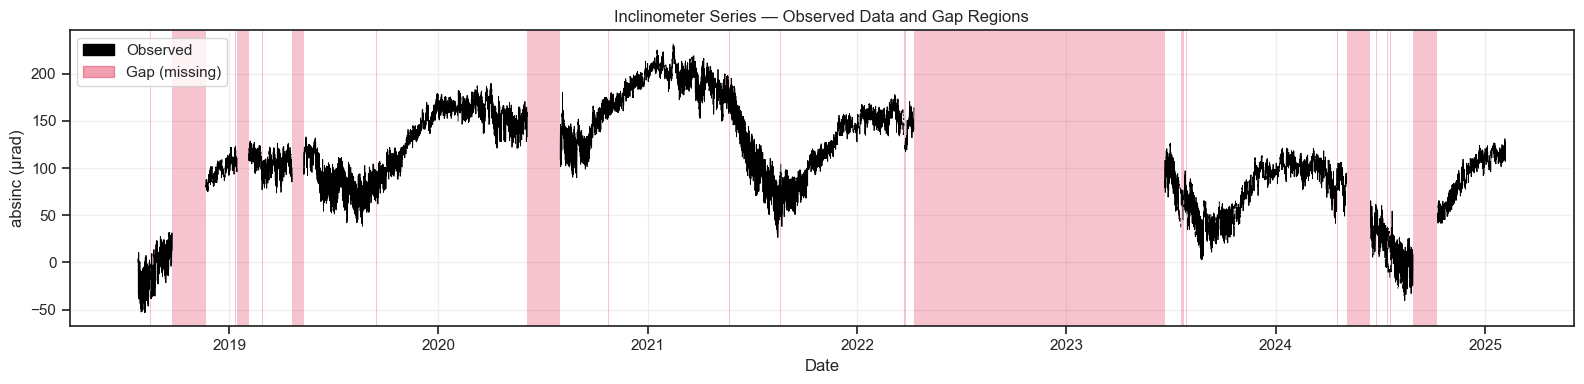

In [6]:
X = build_training_matrix(df_full, PROXY_LAGS, AR_LAGS, TARGET_DIFF)
y = df_full[TARGET_DIFF]

# Drop rows with NaN (either due to missing target or missing lagged features)
valid_idx = X.dropna().index.intersection(y.dropna().index)
X_train = X.loc[valid_idx].copy()
y_train = y.loc[valid_idx].copy()

print(f"Training data shape : {X_train.shape}")
display(pd.DataFrame({"Feature Type": ["Proxy", "AR", "Cyclic"], "Count": [len(PROXY_LAGS), len(AR_LAGS), 6], "Columns": [list(PROXY_LAGS.keys()), [f"{TARGET_DIFF}_lag{l}" for l in AR_LAGS], ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "month_sin", "month_cos"]]}))

## Step 3 · Model Training and Feature Importance

In [8]:
model = XGBRegressor(**XGB_PARAMS)
model.fit(X_train, y_train, verbose=False)

plot_feature_importance(model, save_plot=True, save_path=FIG_PATH, filename="03_02_feature_importance")

Training samples : 36483
Feature columns  : 14

── Table 1 · Feature List ──────────────────────────────────
                             Feature                Type
        skin_temperature (degC)_lag2     Proxy (physics)
surface_solar_radiation (W/m^2)_lag1     Proxy (physics)
        relative_humidity (0-1)_lag0     Proxy (physics)
                            hour_sin       Time encoding
                            hour_cos       Time encoding
                             doy_sin       Time encoding
                             doy_cos       Time encoding
                           month_sin       Time encoding
                           month_cos       Time encoding
                    absinc_diff_lag1 Autoregressive (Δy)
                    absinc_diff_lag2 Autoregressive (Δy)
                    absinc_diff_lag6 Autoregressive (Δy)
                   absinc_diff_lag12 Autoregressive (Δy)
                   absinc_diff_lag24 Autoregressive (Δy)


## Step 4 · Internal Validation (Synthetic Gap)

In [9]:
# Extract synthetic gap window
longest_start, longest_end, longest_len, gap_idx_val = get_synthetic_gap_window(df_full, TARGET, GAP_DURATION_H)
print(f"Testing {GAP_DURATION_H}h synthetic gap inside block {longest_start.strftime('%Y-%m-%d')} → {longest_end.strftime('%Y-%m-%d')}")

# Working copies for iterative filling
working_val = df_full[TARGET].copy()
working_val_diff = df_full[TARGET_DIFF].copy()
working_val.loc[gap_idx_val] = np.nan
working_val_diff.loc[gap_idx_val] = np.nan

y_pred_val = impute_gap_iterative(
    model, gap_idx_val, working_val, working_val_diff, 
    df_full, PROXY_LAGS, AR_LAGS, TARGET, TARGET_DIFF
)

y_true_val = df_full.loc[gap_idx_val, TARGET]
valid_mask, y_true_sc, y_pred_sc, rmse, mae, r2, bias, maxe = evaluate_synthetic_gap(y_true_val, y_pred_val)

metrics_df = pd.DataFrame([{"RMSE (mdeg)": rmse, "MAE (mdeg)": mae, "R²": r2, "Mean Bias (mdeg)": bias, "Max Abs Error": maxe}])
display(metrics_df.round(3))

plot_synthetic_validation(df_full, TARGET, gap_idx_val, y_pred_sc, rmse, valid_mask, GAP_DURATION_H, save_plot=True, save_path=FIG_PATH, filename="03_03_synthetic_validation")

residuals_val = y_pred_sc - y_true_sc
plot_residual_distribution(residuals_val, bias, save_plot=True, save_path=FIG_PATH, filename="03_04_residual_distribution")

Training RMSE (Δy domain) : 1.9163
Training R²   (Δy domain) : 0.6700

Note: R² on differences is structurally lower than on levels.
Reconstruction quality is evaluated on levels in Step 4.

Training residual std σ_cal (Δy domain) : 1.9163  ← used for conformal interval calibration


## Step 5 · Uncertainty Quantification (Bootstrap + Conformal Calibration)

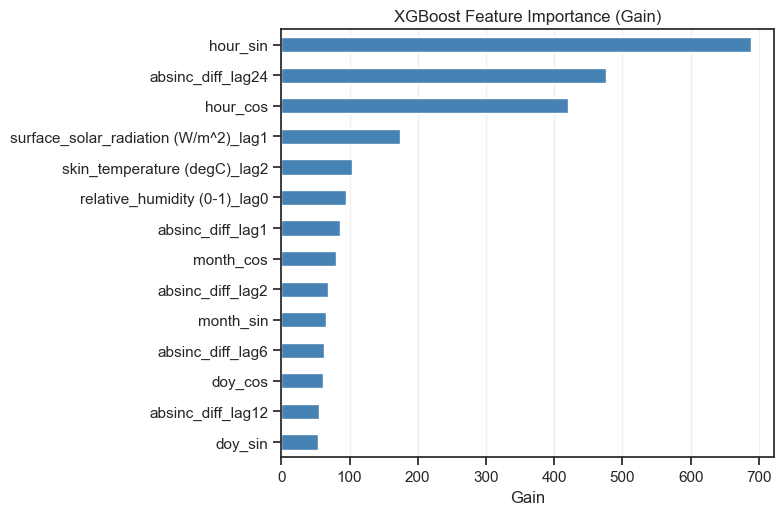

In [10]:
boot_mean, boot_std = get_bootstrap_uncertainty(
    N_BOOTSTRAP, RANDOM_SEED, X_train, y_train, gap_idx_val, 
    working_val, working_val_diff, df_full, PROXY_LAGS, AR_LAGS, TARGET, TARGET_DIFF, XGB_PARAMS
)

residual_std = residuals_val.std()
mean_boot_std, conformal_scale, boot_std_cal = calibrate_uncertainty(boot_std, residual_std)

print(f"\nConformal Calibration Scale : {conformal_scale:.3f}")
print(f"Mean Raw Bootstrap std      : {mean_boot_std:.3f}")

plot_bootstrap_uncertainty(df_full, TARGET, gap_idx_val, boot_mean, boot_std_cal, y_true_val, N_BOOTSTRAP, save_plot=True, save_path=FIG_PATH, filename="03_05_bootstrap_uncertainty")

## Step 6 · Full Gap Imputation Lifecycle

In [11]:
working_full = df_full[TARGET].copy()
working_full_diff = df_full[TARGET_DIFF].copy()

# Inject the logic wrapped in imputation.py
working_full, imputed_flag, imputed_std, log_df = impute_all_gaps_with_uncertainty(
    model, gap_blocks, working_full, working_full_diff, df_full, 
    PROXY_LAGS, AR_LAGS, TARGET, TARGET_DIFF, 
    N_BOOTSTRAP, RANDOM_SEED, X_train, y_train, XGB_PARAMS, conformal_scale
)

display(log_df)

plot_full_reconstruction(df_full, TARGET, working_full, imputed_flag, imputed_std, save_plot=True, save_path=FIG_PATH, filename="03_06_full_reconstruction")
plot_uncertainty_profile(df_full, imputed_std, save_plot=True, save_path=FIG_PATH, filename="03_07_uncertainty_profile")

Longest contiguous block : 2023-12-15 09:00:00 → 2024-03-27 09:00:00 (2472 h)
Synthetic gap window     : 2024-02-01 09:00:00 → 2024-02-08 08:00:00 (168 h)


## Step 7 · Save Reconstructed Output

In [12]:
# Save reconstructed level and gap flag
out_df = pd.DataFrame({
    TARGET: working_full,
    f"{TARGET}_imputed_flag": imputed_flag.astype(int)
}, index=df_full.index)
out_df.to_csv(OUTPUT_PATH)
print(f"Saved level output: {OUTPUT_PATH}")

# Save point-in-time uncertainty explicitly
unc_df = pd.DataFrame({
    f"{TARGET}_sigma": imputed_std
}, index=df_full.index).dropna()
unc_df.to_csv(UNCERTAINTY_PATH)
print(f"Saved uncertainty limits: {UNCERTAINTY_PATH}")


── Table 2 · Reconstruction Metrics (Synthetic Gap, level domain) ──
            Metric   Value
              RMSE 10.3626
               MAE  9.1616
                R² -2.6680
Max Absolute Error 18.5751
 Bias (mean error)  8.9889
